# Project Type Analysis

What kinds of projects do MPs recommend? How long do different project types take to complete?

**Scope:** 17th Lok Sabha only (full 5-year term, better completion data)

**Key insight:** The data has a **workflow pipeline** structure with 3 stages stored as separate rows:
- **Works Recommended**: Initial MP recommendation (has REC_DATE)
- **Works Sanctioned**: Administrative approval (has SANCTION info)
- **Works Completed**: Finished work (has COMP_DATE)

We link records via `WORK_RECOMMENDATION_DTL_ID` (unique project identifier) to compute completion times.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path
import sys

sys.path.insert(0, str(Path(".")))
from _config import COLORS
from _data import load_works_data, get_cleaning_report

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_DIR = Path("../data")

## 1. Data Loading

In [2]:
df, cleaning_stats = load_works_data("ls17", clean=True)

print(f"Total records after cleaning: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print()
print(get_cleaning_report(cleaning_stats))

Total records after cleaning: 241,234
Columns: ['tenure_label', 'tenure_id', 'house', 'state_id', 'state_name', 'constituency_id', 'constituency_name', 'mp_id', 'mp_name', 'tile_label', 'ACTIVITY_NAME', 'ACTUAL_AMOUNT', 'ACTUAL_END_DATE', 'ATTACH_ID', 'AVERAGE_RATING', 'CONSTITUENCY', 'CONSTITUENCY_ID', 'FILE_STATUS', 'FLAG', 'IDA_NAME', 'LETTER_NO', 'MP_NAME', 'RECOMMENDATION_DATE', 'RECOMMENDED_AMOUNT', 'STATE_NAME', 'Sno', 'Total_Amt', 'WORK_CATEGORY', 'WORK_DESCRIPTION', 'WORK_ID', 'WORK_RECOMMENDATION_DTL_ID', '_linkable']

Data Cleaning Report
Original records:         242,358
Not linkable (flagged):     1,671
Cross-MP ambiguous:             0
Zero RECOMMENDED_AMT:         562
Zero ACTUAL_AMT:              562
Invalid rec dates:              0
Future comp dates:              8 (flagged)
----------------------------------------
Total dropped:              1,124
Retained records:         241,234
Retention rate:             99.5%


In [3]:
print("Workflow stage distribution (tile_label):")
print(df['tile_label'].value_counts())

print("\nDate column coverage by stage:")
for stage in df['tile_label'].unique():
    stage_df = df[df['tile_label'] == stage]
    rec_pct = stage_df['RECOMMENDATION_DATE'].notna().mean() * 100
    comp_pct = stage_df['ACTUAL_END_DATE'].notna().mean() * 100
    print(f"  {stage}: REC_DATE={rec_pct:.0f}%, COMP_DATE={comp_pct:.0f}%")

print("\nKey insight: No record has BOTH dates - they're separate workflow stages.")

Workflow stage distribution (tile_label):
tile_label
Works Recommended    94849
Works Sanctioned     91959
Works Completed      54426
Name: count, dtype: int64

Date column coverage by stage:
  Works Recommended: REC_DATE=100%, COMP_DATE=0%
  Works Sanctioned: REC_DATE=99%, COMP_DATE=0%
  Works Completed: REC_DATE=0%, COMP_DATE=100%

Key insight: No record has BOTH dates - they're separate workflow stages.


In [4]:
# Separate workflow stages by tile_label
rec_df = df[df['tile_label'] == 'Works Recommended'].copy()
sanc_df = df[df['tile_label'] == 'Works Sanctioned'].copy()
comp_df = df[df['tile_label'] == 'Works Completed'].copy()

print(f"Records by workflow stage:")
print(f"  Works Recommended: {len(rec_df):,}")
print(f"  Works Sanctioned: {len(sanc_df):,}")
print(f"  Works Completed: {len(comp_df):,}")

print(f"\nLinking key (WORK_RECOMMENDATION_DTL_ID) coverage:")
print(f"  Recommended: {rec_df['WORK_RECOMMENDATION_DTL_ID'].notna().sum():,} ({rec_df['WORK_RECOMMENDATION_DTL_ID'].notna().mean()*100:.1f}%)")
print(f"  Sanctioned: {sanc_df['WORK_RECOMMENDATION_DTL_ID'].notna().sum():,} ({sanc_df['WORK_RECOMMENDATION_DTL_ID'].notna().mean()*100:.1f}%)")
print(f"  Completed: {comp_df['WORK_RECOMMENDATION_DTL_ID'].notna().sum():,} ({comp_df['WORK_RECOMMENDATION_DTL_ID'].notna().mean()*100:.1f}%)")

Records by workflow stage:
  Works Recommended: 94,849
  Works Sanctioned: 91,959
  Works Completed: 54,426

Linking key (WORK_RECOMMENDATION_DTL_ID) coverage:
  Recommended: 94,849 (100.0%)
  Sanctioned: 91,402 (99.4%)
  Completed: 54,426 (100.0%)


In [5]:
print("=== LINKING COVERAGE SUMMARY ===")
print("Records that can be tracked end-to-end via WORK_RECOMMENDATION_DTL_ID:")
print()

link_key = 'WORK_RECOMMENDATION_DTL_ID'
for stage in ['Works Recommended', 'Works Sanctioned', 'Works Completed']:
    stage_df = df[df['tile_label'] == stage]
    if len(stage_df) == 0:
        continue
    has_key = stage_df[link_key].notna().sum()
    total = len(stage_df)
    pct = has_key / total * 100
    print(f"  {stage}: {has_key:,}/{total:,} ({pct:.1f}%) linkable")

total_linkable = df[link_key].notna().sum()
total_records = len(df)
print(f"\n  TOTAL: {total_linkable:,}/{total_records:,} ({total_linkable/total_records*100:.1f}%) records have linking key")
print("\nNote: High linkability (>99%) means minimal selection bias from missing keys.")

=== LINKING COVERAGE SUMMARY ===
Records that can be tracked end-to-end via WORK_RECOMMENDATION_DTL_ID:

  Works Recommended: 94,849/94,849 (100.0%) linkable
  Works Sanctioned: 91,402/91,959 (99.4%) linkable
  Works Completed: 54,426/54,426 (100.0%) linkable

  TOTAL: 240,677/241,234 (99.8%) records have linking key

Note: High linkability (>99%) means minimal selection bias from missing keys.


In [6]:
# WORK_RECOMMENDATION_DTL_ID is unique per-MP, not globally
# Use composite key (WORK_RECOMMENDATION_DTL_ID, mp_id) for linking
link_cols = ['WORK_RECOMMENDATION_DTL_ID', 'mp_id']

rec_ids = set(rec_df[rec_df['WORK_RECOMMENDATION_DTL_ID'].notna()].apply(
    lambda r: (r['WORK_RECOMMENDATION_DTL_ID'], r['mp_id']), axis=1
))
comp_ids = set(comp_df[comp_df['WORK_RECOMMENDATION_DTL_ID'].notna()].apply(
    lambda r: (r['WORK_RECOMMENDATION_DTL_ID'], r['mp_id']), axis=1
))

rec_to_comp_ids = rec_ids & comp_ids

print(f"Composite key (WORK_RECOMMENDATION_DTL_ID, mp_id) matching:")
print(f"  Unique keys in recommended: {len(rec_ids):,}")
print(f"  Unique keys in completed: {len(comp_ids):,}")
print(f"  Recommended → Completed matches: {len(rec_to_comp_ids):,}")

Composite key (WORK_RECOMMENDATION_DTL_ID, mp_id) matching:
  Unique keys in recommended: 94,849
  Unique keys in completed: 54,426
  Recommended → Completed matches: 54,322


In [7]:
# Build lookups using composite key (WORK_RECOMMENDATION_DTL_ID, mp_id)
link_cols = ['WORK_RECOMMENDATION_DTL_ID', 'mp_id']

# Filter to records with valid linking key
rec_linkable = rec_df[rec_df['WORK_RECOMMENDATION_DTL_ID'].notna()].copy()
comp_linkable = comp_df[comp_df['WORK_RECOMMENDATION_DTL_ID'].notna()].copy()

rec_lookup = rec_linkable.groupby(link_cols).agg({
    'RECOMMENDATION_DATE': 'first',
    'RECOMMENDED_AMOUNT': 'first',
    'WORK_DESCRIPTION': 'first',
    'ACTIVITY_NAME': 'first',
    'mp_name': 'first',
    'state_name': 'first',
    'constituency_name': 'first'
}).reset_index()

comp_lookup = comp_linkable.groupby(link_cols).agg({
    'ACTUAL_END_DATE': 'first',
    'ACTUAL_AMOUNT': 'first'
}).reset_index()

merged = rec_lookup.merge(comp_lookup, on=link_cols, how='inner')
print(f"\nMerged records for completion time analysis: {len(merged):,}")


Merged records for completion time analysis: 54,322


In [8]:
merged['rec_date'] = pd.to_datetime(merged['RECOMMENDATION_DATE'], format='%d-%b-%Y', errors='coerce')
merged['comp_date'] = pd.to_datetime(merged['ACTUAL_END_DATE'], format='%d-%b-%Y', errors='coerce')
merged['days_to_complete'] = (merged['comp_date'] - merged['rec_date']).dt.days

valid_days = merged['days_to_complete'].notna() & (merged['days_to_complete'] > 0)
merged = merged[valid_days].copy()
print(f"Records with valid completion time: {len(merged):,}")
print(f"\nCompletion time stats (days):")
print(merged['days_to_complete'].describe())

Records with valid completion time: 53,241

Completion time stats (days):
count    53241.000000
mean       520.312992
std        293.204067
min          1.000000
25%        212.000000
50%        602.000000
75%        744.000000
max       7492.000000
Name: days_to_complete, dtype: float64


## 2. Build Project Taxonomy

Keyword-based classification of project types from `ACTIVITY_NAME` and `WORK_DESCRIPTION`.

In [9]:
def classify_project(activity_name, work_desc):
    """Classify a project based on activity name and description."""
    text = f"{activity_name or ''} {work_desc or ''}".lower()
    
    # Order matters - more specific patterns first
    patterns = [
        ('Vehicle Purchase', r'purchase of (ambulance|vehicle|hearse|school bus)|hearse van'),
        ('Equipment Purchase', r'purchase of (computer|furniture|wheelchair|tricycle)|wheelchair'),
        ('Books/Materials', r'purchase of books|library'),
        ('Tubewell/Handpump', r'tube\s*well|hand\s*pump|bore\s*well|submersible'),
        ('Solar Installation', r'solar (light|street|lamp|panel)'),
        ('Gym Equipment', r'gym equipment|multi[- ]?gym|open gym'),
        ('CC Road', r'cc road|cement concrete road|c\.c\. road|c\.c road'),
        ('Other Road', r'(construction of |laying of |widening of )?(road|pathway|street|lane)(?!.*cc)'),
        ('Community Hall', r'community (hall|center|centre)|panchayat bhawan|kalyan mandap'),
        ('School Building', r'school (building|construction|room)|classroom'),
        ('Drainage', r'drainage|drain|nala|sewer'),
        ('Boundary Wall', r'boundary wall|compound wall|fencing'),
        ('Other Construction', r'construction of'),
        ('Repair/Renovation', r'repair|renovation|restoration|upgradation'),
    ]
    
    for category, pattern in patterns:
        if re.search(pattern, text):
            # Special case: exclude "ambulance road" from vehicle purchase
            if category == 'Vehicle Purchase' and 'ambulance road' in text:
                continue
            return category
    
    return 'Other'

In [10]:
merged['project_type'] = merged.apply(
    lambda row: classify_project(row['ACTIVITY_NAME'], row['WORK_DESCRIPTION']), 
    axis=1
)

print("Project Type Distribution (matched records):")
type_counts = merged['project_type'].value_counts()
for ptype, count in type_counts.items():
    pct = count / len(merged) * 100
    print(f"  {ptype:<20} {count:>6,} ({pct:>5.1f}%)")

classified_pct = (merged['project_type'] != 'Other').mean() * 100
print(f"\nClassified into specific categories: {classified_pct:.1f}%")

Project Type Distribution (matched records):
  Other Road           13,132 ( 24.7%)
  Other                13,070 ( 24.5%)
  Other Construction    6,779 ( 12.7%)
  CC Road               4,441 (  8.3%)
  Solar Installation    4,164 (  7.8%)
  Community Hall        3,630 (  6.8%)
  Tubewell/Handpump     2,319 (  4.4%)
  Drainage              2,208 (  4.1%)
  Boundary Wall         1,155 (  2.2%)
  Books/Materials         802 (  1.5%)
  Gym Equipment           552 (  1.0%)
  Equipment Purchase      402 (  0.8%)
  Repair/Renovation       326 (  0.6%)
  School Building         162 (  0.3%)
  Vehicle Purchase         99 (  0.2%)

Classified into specific categories: 75.5%


In [11]:
# Apply classification to all recommended projects (from rec_df, which has valid WORK_RECOMMENDATION_DTL_ID)
rec_linkable['project_type'] = rec_linkable.apply(
    lambda row: classify_project(row['ACTIVITY_NAME'], row['WORK_DESCRIPTION']), 
    axis=1
)

print("Project Type Distribution (all recommendations with valid linking key):")
all_type_counts = rec_linkable['project_type'].value_counts()
for ptype, count in all_type_counts.items():
    pct = count / len(rec_linkable) * 100
    print(f"  {ptype:<20} {count:>6,} ({pct:>5.1f}%)")

Project Type Distribution (all recommendations with valid linking key):
  Other Road           22,150 ( 23.4%)
  Other                20,376 ( 21.5%)
  Other Construction   14,404 ( 15.2%)
  Community Hall       10,184 ( 10.7%)
  CC Road               7,797 (  8.2%)
  Solar Installation    6,683 (  7.0%)
  Tubewell/Handpump     3,943 (  4.2%)
  Drainage              3,263 (  3.4%)
  Boundary Wall         2,256 (  2.4%)
  Books/Materials       1,243 (  1.3%)
  Gym Equipment           841 (  0.9%)
  Equipment Purchase      623 (  0.7%)
  Repair/Renovation       477 (  0.5%)
  School Building         395 (  0.4%)
  Vehicle Purchase        214 (  0.2%)


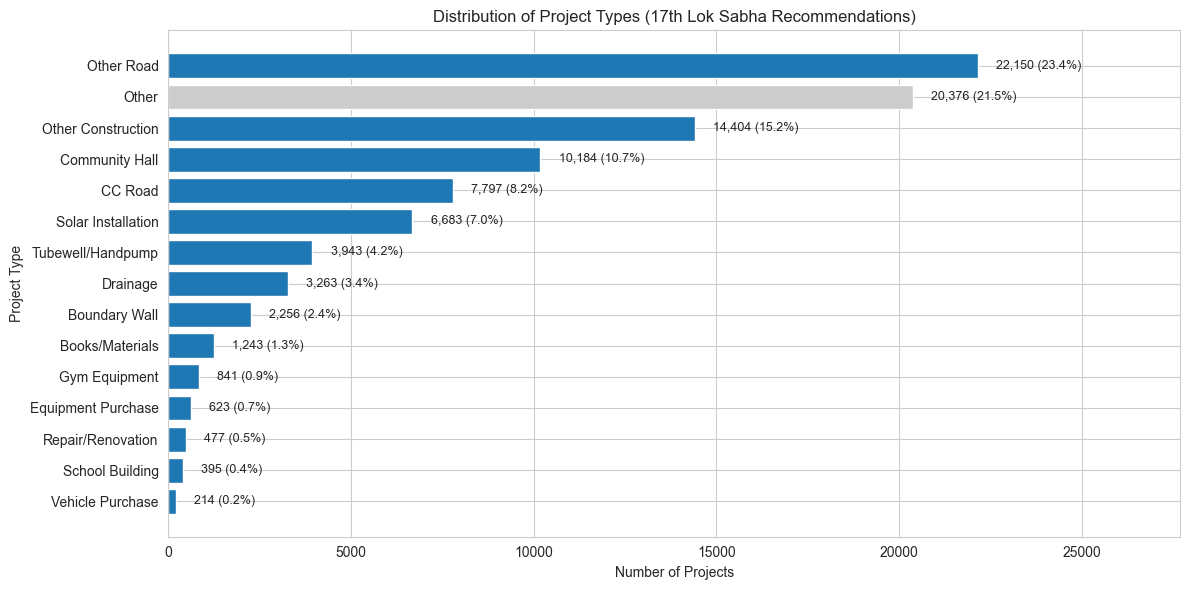

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

type_order = all_type_counts.index.tolist()
colors = [COLORS[0] if t != 'Other' else '#cccccc' for t in type_order]

bars = ax.barh(type_order, all_type_counts.values, color=colors)
ax.set_xlabel('Number of Projects')
ax.set_ylabel('Project Type')
ax.set_title('Distribution of Project Types (17th Lok Sabha Recommendations)')
ax.invert_yaxis()

for bar, count in zip(bars, all_type_counts.values):
    pct = count / len(rec_linkable) * 100
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2, 
            f'{count:,} ({pct:.1f}%)', va='center', fontsize=9)

ax.set_xlim(0, all_type_counts.max() * 1.25)
plt.tight_layout()
plt.savefig(DATA_DIR / 'fig_08_project_types.png', dpi=150)
plt.show()

## 3. Validate Taxonomy with Samples

In [13]:
print("Sample projects by category (using WORK_RECOMMENDATION_DTL_ID linking):\n")
for ptype in ['Vehicle Purchase', 'CC Road', 'Tubewell/Handpump', 'Community Hall', 'Other']:
    print(f"=== {ptype} ===")
    samples = merged[merged['project_type'] == ptype].head(3)
    for _, row in samples.iterrows():
        desc = str(row['WORK_DESCRIPTION'])[:80] if pd.notna(row['WORK_DESCRIPTION']) else 'N/A'
        print(f"  - {desc}...")
    print()

Sample projects by category (using WORK_RECOMMENDATION_DTL_ID linking):

=== Vehicle Purchase ===
  - Late Umanath Singh Swasi Autonomous State Medical College Siddikpur Karanjakala ...
  - Registration formalities for already Dedicated Ambulance to Sewa Samiti J&K at J...
  - Registration Formalities for already Dedicated Ambulance at Cremation  Ground Sh...

=== CC Road ===
  - Construction of CC road in Mrutyunjay Vihar, Sisupalagada, Lingipur...
  - Construction of CC road in village Korada Kanta (Kesura) Dwarikapuri colony main...
  - Construction of CC road at Ananta Vihar, Phase-2, Pokhariput...

=== Tubewell/Handpump ===
  - PROVISION OF DEEP BOARING HAND PUMP (HATHIYA CHAPACAL) IN THE VILLAGE SINGARPUR ...
  - Motor pump installation work with tube well mining for public use, including rec...
  - 05.001 - Installing tube-wells and borewells with Richarge Pit...

=== Community Hall ===
  - Community centre...
  - Community centre...
  - Construction of Community Hall at Khajuri

## 4. Project Size by Type

In [14]:
rec_linkable['amount_lakhs'] = rec_linkable['RECOMMENDED_AMOUNT'] / 1e5

size_stats = rec_linkable.groupby('project_type')['amount_lakhs'].agg(['count', 'mean', 'median', 'std']).round(2)
size_stats.columns = ['N', 'Mean (L)', 'Median (L)', 'Std (L)']
size_stats = size_stats.sort_values('Median (L)', ascending=False)

print("Project Size by Type (Rs. Lakhs):")
print(size_stats.to_string())

Project Size by Type (Rs. Lakhs):
                        N  Mean (L)  Median (L)  Std (L)
project_type                                            
Vehicle Purchase      214     15.10       10.96    13.36
School Building       395      9.70        5.00    12.92
Community Hall      10184      6.15        4.95     7.78
Repair/Renovation     477      6.46        4.95    10.54
Equipment Purchase    623      5.60        4.41    12.62
CC Road              7797      5.05        4.00     5.49
Drainage             3263      5.72        4.00     5.80
Other Construction  14404      5.73        4.00     7.48
Boundary Wall        2256      5.27        3.71     5.70
Gym Equipment         841      6.91        3.50    24.63
Other Road          22150      5.07        3.39     6.98
Other               20376      3.81        2.05    11.11
Tubewell/Handpump    3943      2.34        1.56     3.06
Books/Materials      1243      3.38        0.50     6.76
Solar Installation   6683      1.56        0.21     3.

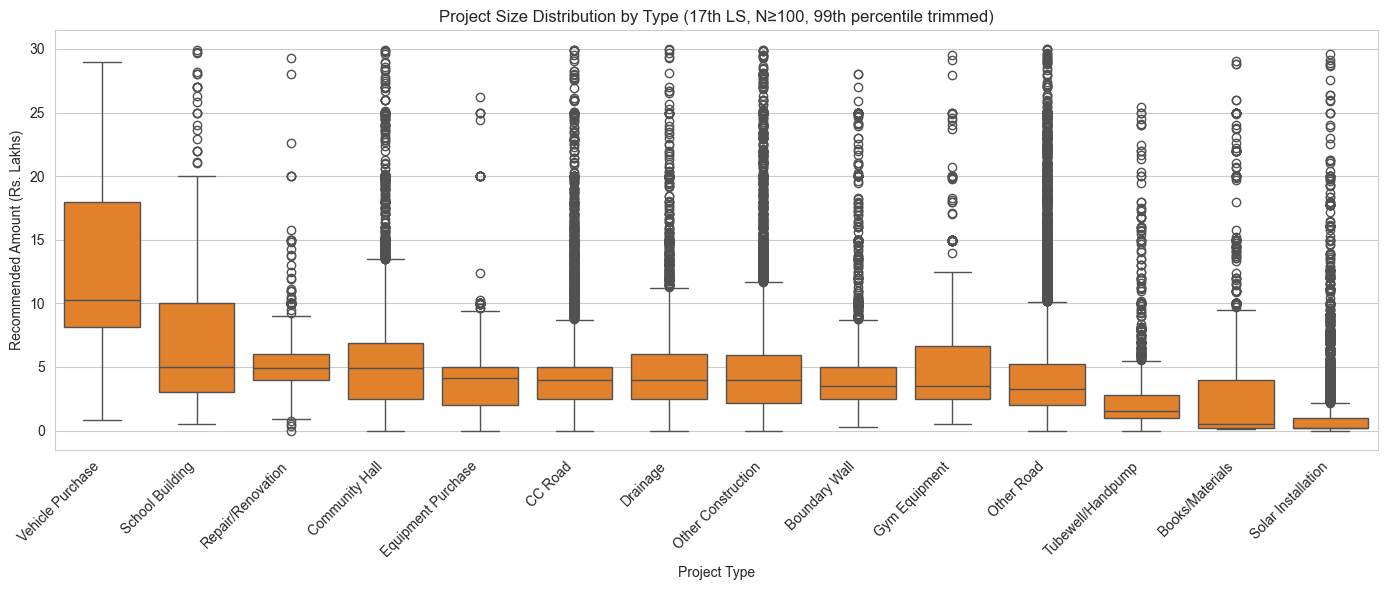

In [15]:
top_types = size_stats[size_stats['N'] >= 100].index.tolist()
if 'Other' in top_types:
    top_types.remove('Other')

fig, ax = plt.subplots(figsize=(14, 6))
plot_data = rec_linkable[rec_linkable['project_type'].isin(top_types)].copy()
plot_data = plot_data[plot_data['amount_lakhs'] < plot_data['amount_lakhs'].quantile(0.99)]

type_medians = plot_data.groupby('project_type')['amount_lakhs'].median().sort_values(ascending=False)
order = type_medians.index.tolist()

sns.boxplot(data=plot_data, x='project_type', y='amount_lakhs', order=order, ax=ax, color=COLORS[1])
ax.set_xlabel('Project Type')
ax.set_ylabel('Recommended Amount (Rs. Lakhs)')
ax.set_title('Project Size Distribution by Type (17th LS, N≥100, 99th percentile trimmed)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Completion Time Analysis with Survival Methods

**Critical insight:** The naive approach of computing median completion time only from *completed* projects introduces **selection bias**—we're ignoring the ~40% of recommendations that never completed (right-censored observations).

**Proper approach:** Use survival analysis (Kaplan-Meier) to account for:
- **Completed projects:** Event observed at completion time
- **Non-completed projects:** Right-censored at reference date (they might complete later)

This gives us unbiased estimates of "What % of projects complete within X time?"

In [16]:
from lifelines import KaplanMeierFitter

REFERENCE_DATE = pd.Timestamp('2026-05-28')

link_cols = ['WORK_RECOMMENDATION_DTL_ID', 'mp_id']

rec_for_surv = rec_linkable[rec_linkable['RECOMMENDATION_DATE'].notna()].copy()
rec_for_surv['rec_date'] = pd.to_datetime(rec_for_surv['RECOMMENDATION_DATE'], format='%d-%b-%Y', errors='coerce')
rec_for_surv = rec_for_surv[rec_for_surv['rec_date'].notna()]

rec_surv_lookup = rec_for_surv.groupby(link_cols).agg({
    'rec_date': 'first',
    'project_type': 'first',
    'state_name': 'first',
    'RECOMMENDED_AMOUNT': 'first'
}).reset_index()

comp_for_surv = comp_linkable.copy()
comp_for_surv['comp_date'] = pd.to_datetime(comp_for_surv['ACTUAL_END_DATE'], format='%d-%b-%Y', errors='coerce')
comp_for_surv = comp_for_surv[comp_for_surv['comp_date'].notna() & (comp_for_surv['comp_date'] <= REFERENCE_DATE)]

comp_surv_lookup = comp_for_surv.groupby(link_cols).agg({
    'comp_date': 'first'
}).reset_index()

surv_df = rec_surv_lookup.merge(comp_surv_lookup, on=link_cols, how='left')

surv_df['completed'] = surv_df['comp_date'].notna()
surv_df['duration'] = np.where(
    surv_df['completed'],
    (surv_df['comp_date'] - surv_df['rec_date']).dt.days,
    (REFERENCE_DATE - surv_df['rec_date']).dt.days
)

surv_df = surv_df[surv_df['duration'] > 0]

print("=== SURVIVAL ANALYSIS DATA ===")
print(f"Total recommendations: {len(surv_df):,}")
print(f"Completed (event observed): {surv_df['completed'].sum():,} ({surv_df['completed'].mean()*100:.1f}%)")
print(f"Pending (right-censored): {(~surv_df['completed']).sum():,} ({(~surv_df['completed']).mean()*100:.1f}%)")
print(f"\nDuration stats (days):")
print(f"  Min: {surv_df['duration'].min():.0f}")
print(f"  Median: {surv_df['duration'].median():.0f}")
print(f"  Max: {surv_df['duration'].max():.0f}")

/Users/soodoku/Documents/GitHub/mplads/.venv/lib/python3.14/site-packages/autograd/wrap_util.py:38: SyntaxWarning: 'return' in a 'finally' block
  return f


=== SURVIVAL ANALYSIS DATA ===
Total recommendations: 93,768
Completed (event observed): 53,233 (56.8%)
Pending (right-censored): 40,535 (43.2%)

Duration stats (days):
  Min: 1
  Median: 805
  Max: 2562


In [17]:
kmf = KaplanMeierFitter()
kmf.fit(surv_df['duration'], event_observed=surv_df['completed'], label='All Projects')

print("=== KAPLAN-MEIER COMPLETION RATES ===")
print("(Accounting for right-censored observations)")
print()

for days, label in [(365, '1 year'), (548, '18 months'), (730, '2 years')]:
    survival_prob = kmf.survival_function_at_times(days).values[0]
    completion_rate = 1 - survival_prob
    
    ci = kmf.confidence_interval_survival_function_.loc[days] if days in kmf.confidence_interval_survival_function_.index else None
    if ci is not None:
        ci_low = 1 - ci.iloc[1]
        ci_high = 1 - ci.iloc[0]
        print(f"{label}: {completion_rate:.1%} completed (95% CI: {ci_low:.1%} - {ci_high:.1%})")
    else:
        print(f"{label}: {completion_rate:.1%} completed")

print(f"\nMedian survival time: {kmf.median_survival_time_:.0f} days ({kmf.median_survival_time_/365:.1f} years)")
print("(Time by which 50% of projects complete)")

=== KAPLAN-MEIER COMPLETION RATES ===
(Accounting for right-censored observations)

1 year: 19.4% completed (95% CI: 19.1% - 19.6%)
18 months: 25.1% completed (95% CI: 24.9% - 25.4%)
2 years: 41.0% completed (95% CI: 40.7% - 41.3%)

Median survival time: 831 days (2.3 years)
(Time by which 50% of projects complete)


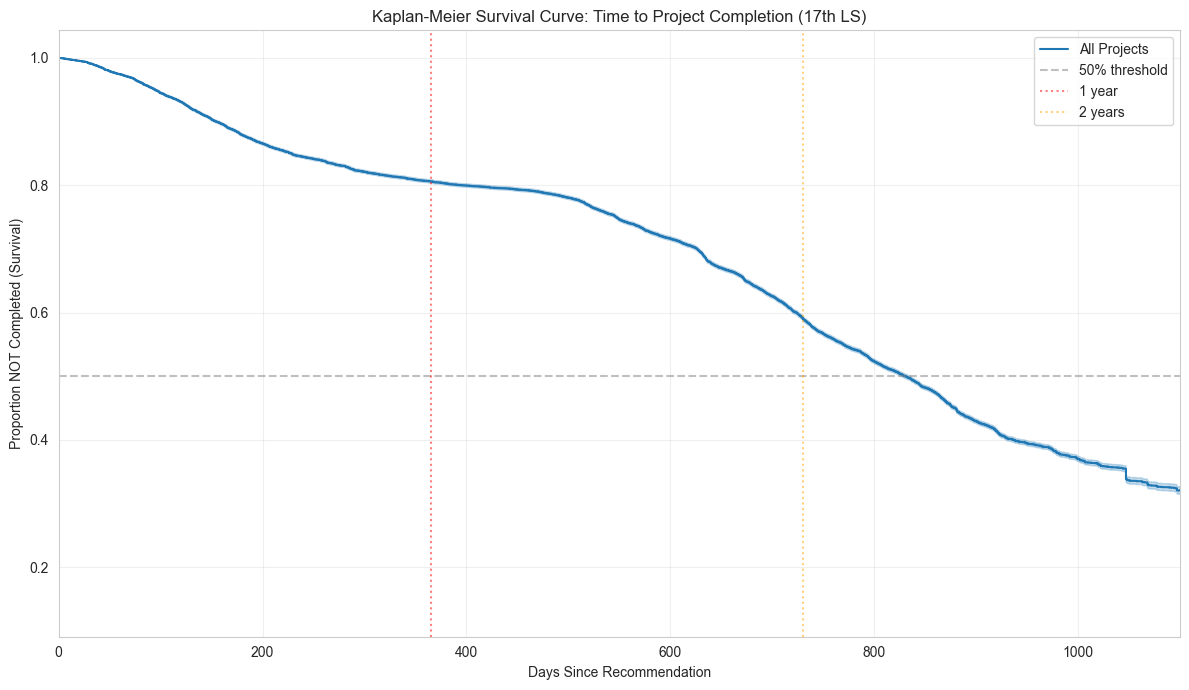


Interpretation: Y-axis shows proportion of projects still 'in progress'.
Lower values = more projects completed. Curve flattening = fewer completions happening.


In [18]:
fig, ax = plt.subplots(figsize=(12, 7))

kmf.plot_survival_function(ax=ax, ci_show=True)

ax.set_xlabel('Days Since Recommendation')
ax.set_ylabel('Proportion NOT Completed (Survival)')
ax.set_title('Kaplan-Meier Survival Curve: Time to Project Completion (17th LS)')

ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
ax.axvline(x=365, color='red', linestyle=':', alpha=0.5, label='1 year')
ax.axvline(x=730, color='orange', linestyle=':', alpha=0.5, label='2 years')

ax.set_xlim(0, 1100)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'fig_09_km_survival_all.png', dpi=150)
plt.show()

print("\nInterpretation: Y-axis shows proportion of projects still 'in progress'.")
print("Lower values = more projects completed. Curve flattening = fewer completions happening.")

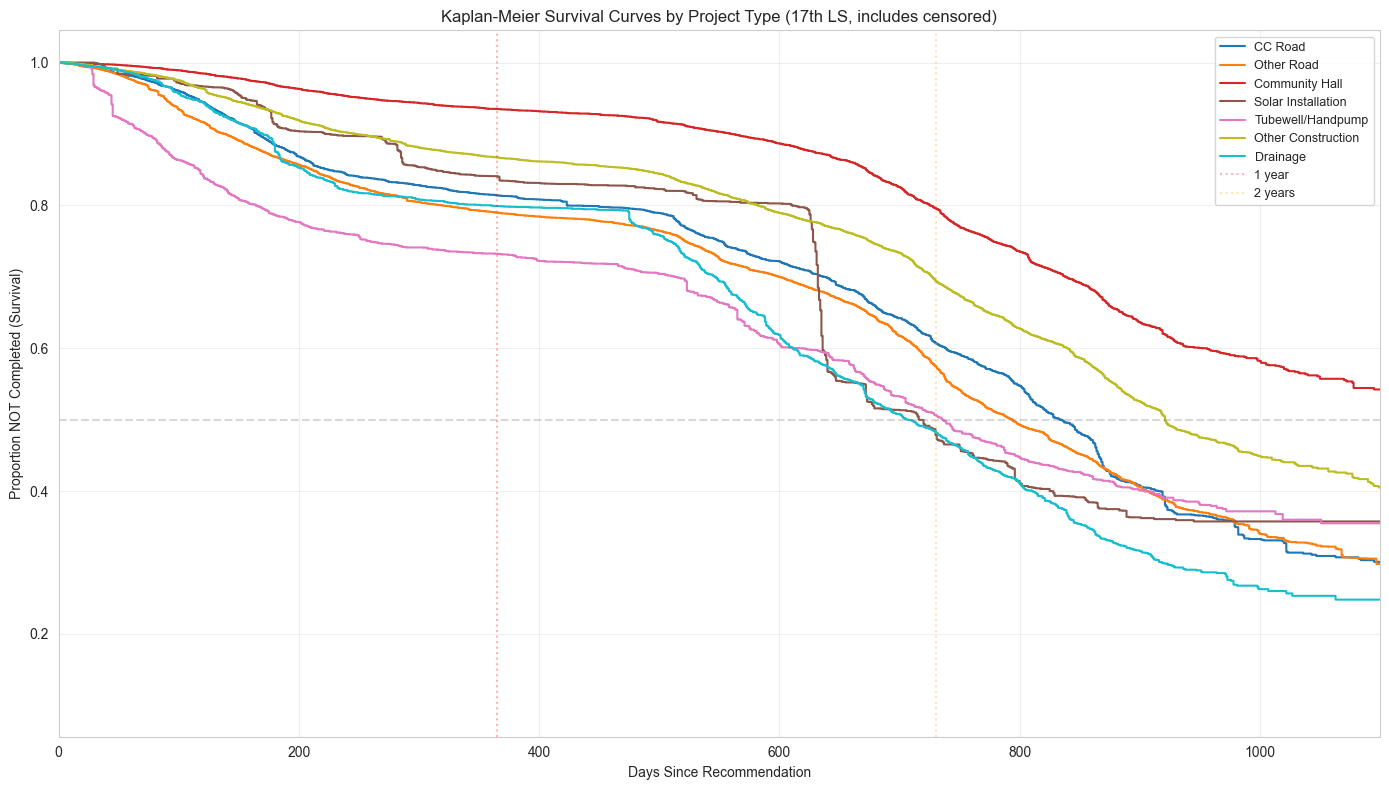

In [19]:
fig, ax = plt.subplots(figsize=(14, 8))

top_types_for_km = ['CC Road', 'Other Road', 'Community Hall', 'Solar Installation', 
                    'Tubewell/Handpump', 'Other Construction', 'Drainage']

colors_km = plt.cm.tab10(np.linspace(0, 1, len(top_types_for_km)))

for i, ptype in enumerate(top_types_for_km):
    subset = surv_df[surv_df['project_type'] == ptype]
    if len(subset) < 100:
        continue
    
    kmf_type = KaplanMeierFitter()
    kmf_type.fit(subset['duration'], event_observed=subset['completed'], label=ptype)
    kmf_type.plot_survival_function(ax=ax, ci_show=False, color=colors_km[i])

ax.set_xlabel('Days Since Recommendation')
ax.set_ylabel('Proportion NOT Completed (Survival)')
ax.set_title('Kaplan-Meier Survival Curves by Project Type (17th LS, includes censored)')

ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
ax.axvline(x=365, color='red', linestyle=':', alpha=0.3, label='1 year')
ax.axvline(x=730, color='orange', linestyle=':', alpha=0.3, label='2 years')

ax.set_xlim(0, 1100)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'fig_09_km_survival_by_type.png', dpi=150)
plt.show()

In [20]:
print("=== COMPLETION RATES BY PROJECT TYPE (Kaplan-Meier) ===")
print("=" * 80)
print(f"{'Project Type':<20} {'N':>8} {'1yr':>10} {'18mo':>10} {'2yr':>10} {'Median':>10}")
print("-" * 80)

km_results = []
for ptype in surv_df['project_type'].unique():
    subset = surv_df[surv_df['project_type'] == ptype]
    if len(subset) < 50:
        continue
    
    kmf_type = KaplanMeierFitter()
    kmf_type.fit(subset['duration'], event_observed=subset['completed'])
    
    row = {'Type': ptype, 'N': len(subset)}
    for days, label in [(365, '1yr'), (548, '18mo'), (730, '2yr')]:
        surv_prob = kmf_type.survival_function_at_times(days).values[0]
        row[label] = (1 - surv_prob) * 100
    
    row['Median'] = kmf_type.median_survival_time_
    km_results.append(row)

km_df = pd.DataFrame(km_results).sort_values('2yr', ascending=False)

for _, row in km_df.iterrows():
    median_str = f"{row['Median']:.0f}d" if pd.notna(row['Median']) and row['Median'] != np.inf else ">max"
    print(f"{row['Type']:<20} {int(row['N']):>8,} {row['1yr']:>9.1f}% {row['18mo']:>9.1f}% {row['2yr']:>9.1f}% {median_str:>10}")

=== COMPLETION RATES BY PROJECT TYPE (Kaplan-Meier) ===
Project Type                N        1yr       18mo        2yr     Median
--------------------------------------------------------------------------------
Repair/Renovation         466      20.8%      27.5%      55.4%       667d
Solar Installation      6,679      16.0%      19.4%      52.1%       716d
Other                  19,977      29.7%      36.5%      52.1%       712d
Drainage                3,228      20.1%      30.3%      51.8%       708d
Tubewell/Handpump       3,922      26.8%      33.5%      49.4%       736d
Gym Equipment             839      28.0%      32.3%      46.5%       790d
Other Road             21,826      21.0%      27.1%      42.6%       794d
Equipment Purchase        617      16.7%      23.8%      40.4%       831d
CC Road                 7,674      18.6%      24.8%      39.3%       834d
Vehicle Purchase          213      17.5%      23.7%      34.8%       >max
Boundary Wall           2,240      13.5%      19.

## 6. Outlier Investigation: Why Do Some Projects Take So Long?

In [21]:
vehicles = merged[merged['project_type'] == 'Vehicle Purchase'].copy()
print(f"Vehicle purchases: {len(vehicles):,}")
print(f"\nCompletion time distribution:")
print(vehicles['days_to_complete'].describe())

print(f"\n\nSlowest vehicle purchases (>1000 days):")
slow_vehicles = vehicles[vehicles['days_to_complete'] > 1000].sort_values('days_to_complete', ascending=False)
for _, row in slow_vehicles.head(5).iterrows():
    desc = str(row['WORK_DESCRIPTION'])[:60] if pd.notna(row['WORK_DESCRIPTION']) else 'N/A'
    print(f"  {row['days_to_complete']:.0f} days: {desc}... ({row['state_name']})")

Vehicle purchases: 99

Completion time distribution:
count     99.000000
mean     476.171717
std      285.313435
min        9.000000
25%      243.000000
50%      542.000000
75%      738.000000
max      914.000000
Name: days_to_complete, dtype: float64


Slowest vehicle purchases (>1000 days):


In [22]:
state_completion = merged.groupby('state_name').agg({
    'days_to_complete': 'median',
    'ACTIVITY_NAME': 'count'
}).rename(columns={'ACTIVITY_NAME': 'N', 'days_to_complete': 'Median Days'})

state_completion = state_completion[state_completion['N'] >= 100].sort_values('Median Days')

print("Completion Time by State (N≥100 projects):")
print("\nFastest states:")
print(state_completion.head(10).to_string())
print("\nSlowest states:")
print(state_completion.tail(10).to_string())

Completion Time by State (N≥100 projects):

Fastest states:
                   Median Days      N
state_name                           
Arunachal Pradesh        222.0    185
Meghalaya                277.0    425
Uttarakhand              292.0   1038
Punjab                   341.0   2942
West Bengal              446.0   2891
Kerala                   467.0   2325
Gujarat                  535.0   4845
Bihar                    538.0   5289
Jharkhand                564.0    641
Uttar Pradesh            572.0  10791

Slowest states:
                  Median Days     N
state_name                         
Odisha                  696.0  1982
Delhi                   714.0   260
Assam                   720.5   422
Himachal Pradesh        721.0   459
Andhra Pradesh          726.0  2194
Maharashtra             729.0  2652
Rajasthan               735.0  2281
Telangana               749.0  1372
Tripura                 769.0   112
Tamil Nadu              775.0  2284


## 7. Summary Table

In [23]:
link_key = 'WORK_RECOMMENDATION_DTL_ID'
summary = merged.groupby('project_type').agg({
    link_key: 'count',
    'RECOMMENDED_AMOUNT': 'median',
    'days_to_complete': 'median'
}).rename(columns={
    link_key: 'N Completed',
    'RECOMMENDED_AMOUNT': 'Median Amount (Rs)',
    'days_to_complete': 'Median Days'
})

summary['Median Amount (L)'] = (summary['Median Amount (Rs)'] / 1e5).round(1)
summary['Median Years'] = (summary['Median Days'] / 365).round(1)
summary = summary[['N Completed', 'Median Amount (L)', 'Median Days', 'Median Years']]
summary = summary.sort_values('Median Days')

print("=" * 70)
print("SUMMARY: Project Types by Completion Time (WORK_RECOMMENDATION_DTL_ID linking)")
print("=" * 70)
print(summary.to_string())

SUMMARY: Project Types by Completion Time (WORK_RECOMMENDATION_DTL_ID linking)
                    N Completed  Median Amount (L)  Median Days  Median Years
project_type                                                                 
Other                     13070                2.0        493.0           1.4
Tubewell/Handpump          2319                1.8        505.0           1.4
Vehicle Purchase             99               15.0        542.0           1.5
Gym Equipment               552                3.2        564.0           1.5
Drainage                   2208                4.4        573.0           1.6
Repair/Renovation           326                4.9        589.0           1.6
Other Road                13132                3.4        602.5           1.7
CC Road                    4441                4.6        621.0           1.7
Solar Installation         4164                0.2        632.0           1.7
Other Construction         6779                4.0        657.0

In [24]:
print("\n" + "=" * 70)
print("KEY TAKEAWAYS")
print("=" * 70)

if len(summary) > 0:
    fastest = summary['Median Days'].idxmin()
    slowest = summary['Median Days'].idxmax()
    print(f"\n1. FASTEST: {fastest} ({summary.loc[fastest, 'Median Days']:.0f} days median)")
    print(f"   SLOWEST: {slowest} ({summary.loc[slowest, 'Median Days']:.0f} days median)")

    vehicle_days = summary.loc['Vehicle Purchase', 'Median Days'] if 'Vehicle Purchase' in summary.index else None
    construction_days = summary.loc['CC Road', 'Median Days'] if 'CC Road' in summary.index else None

    if vehicle_days and construction_days:
        print(f"\n2. SURPRISE: Vehicle purchases ({vehicle_days:.0f}d) take nearly as long as CC roads ({construction_days:.0f}d)!")
        print("   This suggests completion time is driven more by bureaucratic process than project complexity.")

    total_matched = len(merged)
    total_rec = len(rec_linkable)
    print(f"\n3. DATA COVERAGE: {total_matched:,} projects with completion times ({total_matched/total_rec*100:.1f}% of recommendations)")

    print(f"\n4. OVERALL: Median completion time across all types is {merged['days_to_complete'].median():.0f} days ({merged['days_to_complete'].median()/365:.1f} years)")
else:
    print("\nNo completed projects found with valid completion times.")


KEY TAKEAWAYS

1. FASTEST: Other (493 days median)
   SLOWEST: Books/Materials (796 days median)

2. SURPRISE: Vehicle purchases (542d) take nearly as long as CC roads (621d)!
   This suggests completion time is driven more by bureaucratic process than project complexity.

3. DATA COVERAGE: 53,241 projects with completion times (56.1% of recommendations)

4. OVERALL: Median completion time across all types is 602 days (1.6 years)


In [25]:
print(f"\nFigures saved:")
print(f"  - {DATA_DIR / 'fig_08_project_types.png'}")
print(f"  - {DATA_DIR / 'fig_09_completion_time.png'}")


Figures saved:
  - ../data/fig_08_project_types.png
  - ../data/fig_09_completion_time.png


## 8. Survival Analysis: Accounting for Right-Censoring

The completion time analysis above is **biased**: it only looks at projects that *actually completed*. But ~40% of recommendations never completed. These "censored" observations contain important information.

A better question: **What % of recommendations are completed by 1 or 2 years?**

**Data limitation:** The eSAKSHI portal only has data from FY 2023-24 onwards, so most recommendation dates are from 2023-2024 even though this is 17th LS (2019-2024). We use May 2026 as reference to allow 2+ years for most projects.

In [26]:
REFERENCE_DATE = pd.Timestamp('2026-05-01')

rec_df['rec_date'] = pd.to_datetime(rec_df['RECOMMENDATION_DATE'], format='%d-%b-%Y', errors='coerce')

print("Recommendation dates by year:")
rec_df['rec_year'] = rec_df['rec_date'].dt.year
year_counts = rec_df['rec_year'].value_counts().sort_index()
for year, count in year_counts.items():
    print(f"  {int(year)}: {count:,}")

print(f"\nNote: 99% of records are from 2023-2024 due to eSAKSHI portal data availability.")
print(f"This limits survival analysis to 1-2 year horizons.")

Recommendation dates by year:
  2019: 51
  2020: 66
  2021: 49
  2022: 739
  2023: 50,000
  2024: 43,331
  2025: 572
  2026: 41

Note: 99% of records are from 2023-2024 due to eSAKSHI portal data availability.
This limits survival analysis to 1-2 year horizons.


In [27]:
# Build survival dataset using composite key (WORK_RECOMMENDATION_DTL_ID, mp_id)
link_cols = ['WORK_RECOMMENDATION_DTL_ID', 'mp_id']

# Filter to linkable records
comp_lookup_full = comp_linkable.groupby(link_cols).agg({
    'ACTUAL_END_DATE': 'first'
}).reset_index()
comp_lookup_full['comp_date'] = pd.to_datetime(comp_lookup_full['ACTUAL_END_DATE'], format='%d-%b-%Y', errors='coerce')
comp_lookup_full = comp_lookup_full[comp_lookup_full['comp_date'] <= REFERENCE_DATE]

rec_lookup_surv = rec_linkable[rec_linkable['RECOMMENDATION_DATE'].notna()].copy()
rec_lookup_surv['rec_date'] = pd.to_datetime(rec_lookup_surv['RECOMMENDATION_DATE'], format='%d-%b-%Y', errors='coerce')
rec_lookup_surv = rec_lookup_surv[rec_lookup_surv['rec_date'].notna()].groupby(link_cols).agg({
    'rec_date': 'first',
    'project_type': 'first',
    'state_name': 'first'
}).reset_index()

survival_df = rec_lookup_surv.merge(
    comp_lookup_full[link_cols + ['comp_date']], 
    on=link_cols, 
    how='left'
)

survival_df['completed'] = survival_df['comp_date'].notna()
survival_df['days_to_complete'] = (survival_df['comp_date'] - survival_df['rec_date']).dt.days
survival_df['days_available'] = (REFERENCE_DATE - survival_df['rec_date']).dt.days

print(f"Unique projects (composite key): {len(survival_df):,}")
print(f"Eventually completed: {survival_df['completed'].sum():,} ({survival_df['completed'].mean()*100:.1f}%)")
print(f"Pending (censored): {(~survival_df['completed']).sum():,} ({(~survival_df['completed']).mean()*100:.1f}%)")

Unique projects (composite key): 94,849
Eventually completed: 53,284 (56.2%)
Pending (censored): 41,565 (43.8%)


In [28]:
print("COMPLETION RATES BY TIME POINT (Survival-style)")
print("=" * 70)
print("% of projects that complete within X time, counting ALL recommendations")
print()

for days, label in [(365, '1 year'), (730, '2 years')]:
    eligible = survival_df[survival_df['days_available'] >= days]
    completed_within = (
        eligible['completed'] & 
        (eligible['days_to_complete'] > 0) &
        (eligible['days_to_complete'] <= days)
    ).sum()
    rate = completed_within / len(eligible) * 100 if len(eligible) > 0 else 0
    print(f"{label}: {rate:.1f}% completed")
    print(f"         N eligible: {len(eligible):,}, Completed within: {completed_within:,}")
    print()

COMPLETION RATES BY TIME POINT (Survival-style)
% of projects that complete within X time, counting ALL recommendations

1 year: 19.2% completed
         N eligible: 94,371, Completed within: 18,098

2 years: 40.5% completed
         N eligible: 94,059, Completed within: 38,074



In [29]:
print("COMPLETION RATES BY PROJECT TYPE")
print("=" * 80)
print(f"{'Type':<20} {'N Rec':>8} {'1yr':>8} {'2yr':>8}")
print("-" * 80)

results = []
for ptype in survival_df['project_type'].unique():
    ptype_df = survival_df[survival_df['project_type'] == ptype]
    row = {'Type': ptype, 'N': len(ptype_df)}
    
    for days, label in [(365, '1yr'), (730, '2yr')]:
        eligible = ptype_df[ptype_df['days_available'] >= days]
        if len(eligible) == 0:
            row[label] = np.nan
            continue
        completed = (
            eligible['completed'] &
            (eligible['days_to_complete'] > 0) &
            (eligible['days_to_complete'] <= days)
        ).sum()
        row[label] = completed / len(eligible) * 100
    
    results.append(row)

survival_results = pd.DataFrame(results).sort_values('2yr', ascending=False)
for _, row in survival_results.iterrows():
    yr1 = f"{row['1yr']:.1f}%" if pd.notna(row['1yr']) else 'N/A'
    yr2 = f"{row['2yr']:.1f}%" if pd.notna(row['2yr']) else 'N/A'
    print(f"{row['Type']:<20} {row['N']:>8,} {yr1:>8} {yr2:>8}")

COMPLETION RATES BY PROJECT TYPE
Type                    N Rec      1yr      2yr
--------------------------------------------------------------------------------
Solar Installation      6,683    16.0%    52.1%
Repair/Renovation         477    20.4%    51.8%
Drainage                3,263    19.8%    51.3%
Other                  20,376    29.1%    51.1%
Tubewell/Handpump       3,943    26.8%    49.2%
Gym Equipment             841    27.9%    46.5%
Other Road             22,150    20.7%    42.0%
Equipment Purchase        623    16.5%    40.0%
CC Road                 7,797    18.4%    38.3%
Vehicle Purchase          214    17.6%    34.8%
Boundary Wall           2,256    13.5%    32.2%
Other Construction     14,404    13.1%    30.3%
Books/Materials         1,243     7.2%    29.1%
School Building           395     8.9%    22.3%
Community Hall         10,184     6.4%    20.2%


### Selection Bias in "Median Completion Time"

The earlier "median completion time" analysis (Section 5) only looks at projects that actually completed. This creates **selection bias** - we're only seeing the subset that finished, ignoring the 40%+ that never completed.

In [30]:
print("Completion rates by project type (using WORK_RECOMMENDATION_DTL_ID linking):")
print("=" * 70)
print(f"{'Type':<20} {'All Recs':>10} {'Completed':>10} {'Rate':>8}")
print("-" * 70)

link_key = 'WORK_RECOMMENDATION_DTL_ID'
all_type_counts = rec_linkable.groupby('project_type')[link_key].nunique()
completed_type_counts = merged['project_type'].value_counts()

for ptype in all_type_counts.sort_values(ascending=False).index:
    n_all = all_type_counts.get(ptype, 0)
    n_comp = completed_type_counts.get(ptype, 0)
    rate = n_comp / n_all * 100 if n_all > 0 else 0
    print(f"{ptype:<20} {n_all:>10,} {n_comp:>10,} {rate:>7.1f}%")

total_all = all_type_counts.sum()
total_comp = completed_type_counts.sum()
print("-" * 70)
print(f"{'TOTAL':<20} {total_all:>10,} {total_comp:>10,} {total_comp/total_all*100:>7.1f}%")

Completion rates by project type (using WORK_RECOMMENDATION_DTL_ID linking):
Type                   All Recs  Completed     Rate
----------------------------------------------------------------------
Other Road               22,146     13,132    59.3%
Other                    20,373     13,070    64.2%
Other Construction       14,403      6,779    47.1%
Community Hall           10,182      3,630    35.7%
CC Road                   7,797      4,441    57.0%
Solar Installation        6,683      4,164    62.3%
Tubewell/Handpump         3,943      2,319    58.8%
Drainage                  3,263      2,208    67.7%
Boundary Wall             2,256      1,155    51.2%
Books/Materials           1,243        802    64.5%
Gym Equipment               841        552    65.6%
Equipment Purchase          623        402    64.5%
Repair/Renovation           477        326    68.3%
School Building             395        162    41.0%
Vehicle Purchase            214         99    46.3%
--------------------

### Cumulative Completion Curves

Plot showing what % of projects complete over time, by project type.

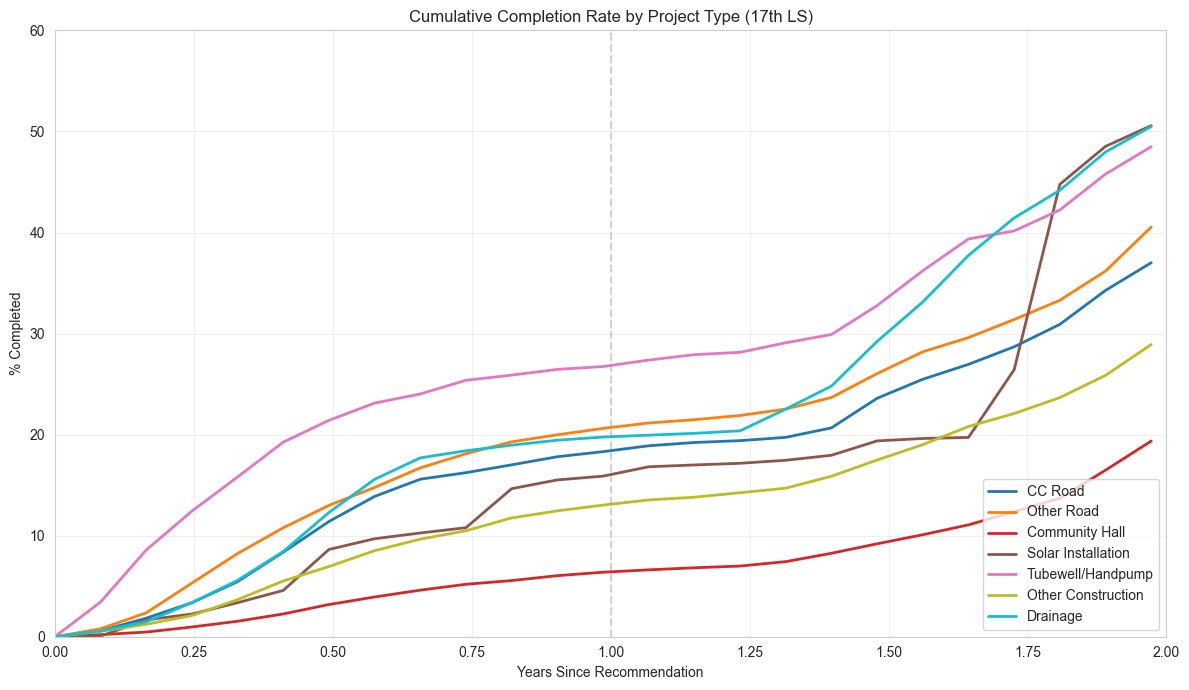

In [31]:
def calc_cumulative_completion(df, max_days=730, step=30):
    """Calculate cumulative completion % over time for each project type."""
    time_points = range(0, max_days + 1, step)
    results = []
    
    for ptype in df['project_type'].unique():
        ptype_df = df[df['project_type'] == ptype]
        
        for days in time_points:
            eligible = ptype_df[ptype_df['days_available'] >= days]
            if len(eligible) < 100:
                continue
            
            completed_by = (
                eligible['completed'] & 
                (eligible['days_to_complete'] > 0) &
                (eligible['days_to_complete'] <= days)
            ).sum()
            
            pct_completed = completed_by / len(eligible) * 100
            
            results.append({
                'project_type': ptype,
                'days': days,
                'pct_completed': pct_completed,
                'n_eligible': len(eligible)
            })
    
    return pd.DataFrame(results)

top_types_km = ['CC Road', 'Other Road', 'Community Hall', 'Solar Installation', 
                'Tubewell/Handpump', 'Other Construction', 'Drainage']
km_df = survival_df[survival_df['project_type'].isin(top_types_km)]
cumulative = calc_cumulative_completion(km_df)

fig, ax = plt.subplots(figsize=(12, 7))

colors_km = plt.cm.tab10(np.linspace(0, 1, len(top_types_km)))
for i, ptype in enumerate(top_types_km):
    ptype_data = cumulative[cumulative['project_type'] == ptype].sort_values('days')
    if len(ptype_data) > 0:
        ax.plot(ptype_data['days'] / 365, ptype_data['pct_completed'], 
                label=ptype, linewidth=2, color=colors_km[i])

ax.set_xlabel('Years Since Recommendation')
ax.set_ylabel('% Completed')
ax.set_title('Cumulative Completion Rate by Project Type (17th LS)')
ax.legend(loc='lower right')
ax.set_xlim(0, 2)
ax.set_ylim(0, 60)
ax.axvline(x=1, color='gray', linestyle='--', alpha=0.3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'fig_10_survival_completion.png', dpi=150)
plt.show()

In [32]:
print("\nFigure saved: fig_10_survival_completion.png")


Figure saved: fig_10_survival_completion.png


## 8.5 Buy vs Build: Completion Times by Project Nature

Does procurement ("Buy") complete faster than construction ("Build")?

Classify projects:
- **Buy**: Purchases, procurement, equipment acquisition
- **Build**: Construction, infrastructure creation

In [33]:
def classify_buy_build(project_type):
    """Classify project as Buy (procurement) or Build (construction)."""
    buy_types = ['Vehicle Purchase', 'Equipment Purchase', 'Books/Materials', 'Gym Equipment']
    build_types = ['CC Road', 'Other Road', 'Community Hall', 'School Building', 
                   'Other Construction', 'Drainage', 'Boundary Wall', 'Tubewell/Handpump']
    
    if project_type in buy_types:
        return 'Buy'
    elif project_type in build_types:
        return 'Build'
    else:
        return 'Other'

merged['buy_build'] = merged['project_type'].apply(classify_buy_build)

print("BUY VS BUILD CLASSIFICATION")
print("=" * 70)
print("\nClassification mapping:")
print("  Buy: Vehicle Purchase, Equipment Purchase, Books/Materials, Gym Equipment")
print("  Build: Roads, Community Hall, School Building, Construction, Drainage, etc.")

print("\n\nDistribution:")
for bb, count in merged['buy_build'].value_counts().items():
    pct = count / len(merged) * 100
    print(f"  {bb:<10} {count:>6,} ({pct:.1f}%)")

BUY VS BUILD CLASSIFICATION

Classification mapping:
  Buy: Vehicle Purchase, Equipment Purchase, Books/Materials, Gym Equipment
  Build: Roads, Community Hall, School Building, Construction, Drainage, etc.


Distribution:
  Build      33,826 (63.5%)
  Other      17,560 (33.0%)
  Buy         1,855 (3.5%)


In [34]:
print("COMPLETION TIME: BUY VS BUILD")
print("=" * 70)

buy_data = merged[merged['buy_build'] == 'Buy']['days_to_complete']
build_data = merged[merged['buy_build'] == 'Build']['days_to_complete']

print(f"\nBuy (Procurement):")
print(f"  N: {len(buy_data):,}")
print(f"  Median: {buy_data.median():.0f} days ({buy_data.median()/365:.1f} years)")
print(f"  Mean: {buy_data.mean():.0f} days")
print(f"  25th-75th: {buy_data.quantile(0.25):.0f} - {buy_data.quantile(0.75):.0f} days")

print(f"\nBuild (Construction):")
print(f"  N: {len(build_data):,}")
print(f"  Median: {build_data.median():.0f} days ({build_data.median()/365:.1f} years)")
print(f"  Mean: {build_data.mean():.0f} days")
print(f"  25th-75th: {build_data.quantile(0.25):.0f} - {build_data.quantile(0.75):.0f} days")

ratio = buy_data.median() / build_data.median() * 100
print(f"\n" + "=" * 70)
print(f"RESULT: Buy takes {ratio:.0f}% as long as Build")
if ratio > 100:
    print(f"        Buy is SLOWER than Build by {ratio-100:.0f}%")
else:
    print(f"        Buy is FASTER than Build by {100-ratio:.0f}%")
print("=" * 70)

print("\nNOTE: Surprisingly, procurement projects don't complete faster.")
print("This suggests completion time is driven by bureaucratic process,")
print("not by physical construction complexity.")

COMPLETION TIME: BUY VS BUILD

Buy (Procurement):
  N: 1,855
  Median: 685 days (1.9 years)
  Mean: 593 days
  25th-75th: 358 - 852 days

Build (Construction):
  N: 33,826
  Median: 623 days (1.7 years)
  Mean: 542 days
  25th-75th: 237 - 762 days

RESULT: Buy takes 110% as long as Build
        Buy is SLOWER than Build by 10%

NOTE: Surprisingly, procurement projects don't complete faster.
This suggests completion time is driven by bureaucratic process,
not by physical construction complexity.


## Q6: State Administrative Capacity Ranking

**IMPORTANT CAVEATS:**
1. This measures **implementation capacity conditional on recommendations** - states must have projects recommended to measure completion
2. Low-capacity states may have fewer recommendations in the first place (selection effect)
3. This is a **throughput measure**, not an overall effectiveness measure
4. Completion rates depend on project mix, which varies by state

In [35]:
print("Q6: STATE ADMINISTRATIVE CAPACITY")
print("=" * 80)
print("\nCONTEXT: Recommendation rates by state (to understand selection)")
print("-" * 80)

link_key = 'WORK_RECOMMENDATION_DTL_ID'
rec_by_state = rec_linkable.groupby('state_name').agg({
    link_key: 'nunique',
    'mp_id': 'nunique'
}).reset_index()
rec_by_state.columns = ['State', 'N_Recommendations', 'N_MPs']
rec_by_state['Recs_per_MP'] = rec_by_state['N_Recommendations'] / rec_by_state['N_MPs']
rec_by_state = rec_by_state.sort_values('Recs_per_MP', ascending=False)

print(f"\n{'State':<25} {'N Recs':>10} {'N MPs':>8} {'Recs/MP':>10}")
print("-" * 80)
for _, row in rec_by_state.head(10).iterrows():
    print(f"{row['State']:<25} {row['N_Recommendations']:>10,} {row['N_MPs']:>8} {row['Recs_per_MP']:>10.0f}")
print("...")
for _, row in rec_by_state.tail(5).iterrows():
    print(f"{row['State']:<25} {row['N_Recommendations']:>10,} {row['N_MPs']:>8} {row['Recs_per_MP']:>10.0f}")

Q6: STATE ADMINISTRATIVE CAPACITY

CONTEXT: Recommendation rates by state (to understand selection)
--------------------------------------------------------------------------------

State                         N Recs    N MPs    Recs/MP
--------------------------------------------------------------------------------
Uttarakhand                    2,155        4        539
Himachal Pradesh               1,747        4        437
Meghalaya                        549        2        274
Odisha                         5,644       21        269
Madhya Pradesh                 7,695       29        265
Punjab                         3,372       13        259
Gujarat                        6,700       26        258
Telangana                      4,334       17        255
Jharkhand                      2,761       13        212
Jammu And Kashmir                833        4        208
...
Sikkim                            55        1         55
Lakshadweep                       45        1    

In [36]:
print("\nSTATE COMPLETION RATES (Survival-style, at 1yr and 2yr horizons)")
print("=" * 80)
print("(Only states with N >= 100 eligible recommendations)")
print("-" * 80)

state_capacity = []
for state in survival_df['state_name'].dropna().unique():
    state_df = survival_df[survival_df['state_name'] == state]
    
    row = {'State': state}
    for days, label in [(365, '1yr'), (730, '2yr')]:
        eligible = state_df[state_df['days_available'] >= days]
        if len(eligible) >= 100:
            completed_within = (
                eligible['completed'] & 
                (eligible['days_to_complete'] > 0) &
                (eligible['days_to_complete'] <= days)
            ).sum()
            row[label] = completed_within / len(eligible) * 100
            row[f'{label}_N'] = len(eligible)
        else:
            row[label] = np.nan
            row[f'{label}_N'] = len(eligible)
    
    state_capacity.append(row)

capacity_df = pd.DataFrame(state_capacity)
capacity_df = capacity_df[capacity_df['2yr'].notna()].sort_values('2yr', ascending=False)

print(f"\n{'State':<25} {'1yr Rate':>10} {'2yr Rate':>10} {'N (2yr)':>10}")
print("-" * 80)
print("FASTEST (highest completion rates):")
for _, row in capacity_df.head(10).iterrows():
    yr1 = f"{row['1yr']:.1f}%" if pd.notna(row['1yr']) else 'N/A'
    yr2 = f"{row['2yr']:.1f}%" if pd.notna(row['2yr']) else 'N/A'
    print(f"{row['State']:<25} {yr1:>10} {yr2:>10} {int(row['2yr_N']):>10,}")

print("\nSLOWEST (lowest completion rates):")
for _, row in capacity_df.tail(10).iterrows():
    yr1 = f"{row['1yr']:.1f}%" if pd.notna(row['1yr']) else 'N/A'
    yr2 = f"{row['2yr']:.1f}%" if pd.notna(row['2yr']) else 'N/A'
    print(f"{row['State']:<25} {yr1:>10} {yr2:>10} {int(row['2yr_N']):>10,}")


STATE COMPLETION RATES (Survival-style, at 1yr and 2yr horizons)
(Only states with N >= 100 eligible recommendations)
--------------------------------------------------------------------------------

State                       1yr Rate   2yr Rate    N (2yr)
--------------------------------------------------------------------------------
FASTEST (highest completion rates):
Bihar                          35.2%      80.8%      5,654
Meghalaya                      44.4%      70.1%        549
Punjab                         46.1%      66.9%      3,372
Kerala                         32.6%      63.9%      3,096
Gujarat                        22.3%      62.0%      6,558
Uttar Pradesh                  30.3%      60.3%     14,727
Manipur                        33.9%      57.1%        112
Chhattisgarh                   23.0%      55.1%      1,597
Jammu And Kashmir              22.8%      41.9%        833
West Bengal                    20.7%      41.5%      6,084

SLOWEST (lowest completion rates

In [37]:
print("\n" + "=" * 80)
print("STATE CAPACITY INTERPRETATION")
print("=" * 80)

print("\nCAVEATS (repeated for emphasis):")
print("  1. This is completion CONDITIONAL ON recommendation")
print("  2. Low-capacity states may have fewer recommendations to begin with")
print("  3. Project mix differs by state (infrastructure vs procurement)")
print("  4. Implementation depends on state IDA (nodal agency) efficiency")

avg_1yr = capacity_df['1yr'].mean()
avg_2yr = capacity_df['2yr'].mean()
print(f"\nNATIONAL AVERAGES:")
print(f"  1-year completion rate: {avg_1yr:.1f}%")
print(f"  2-year completion rate: {avg_2yr:.1f}%")

top_states = capacity_df.head(5)['State'].tolist()
bottom_states = capacity_df.tail(5)['State'].tolist()
print(f"\nTOP 5 STATES: {', '.join(top_states)}")
print(f"BOTTOM 5 STATES: {', '.join(bottom_states)}")


STATE CAPACITY INTERPRETATION

CAVEATS (repeated for emphasis):
  1. This is completion CONDITIONAL ON recommendation
  2. Low-capacity states may have fewer recommendations to begin with
  3. Project mix differs by state (infrastructure vs procurement)
  4. Implementation depends on state IDA (nodal agency) efficiency

NATIONAL AVERAGES:
  1-year completion rate: 18.0%
  2-year completion rate: 36.0%

TOP 5 STATES: Bihar, Meghalaya, Punjab, Kerala, Gujarat
BOTTOM 5 STATES: Telangana, Himachal Pradesh, Assam, Goa, Tripura


## 9. Cross-Body Comparison (LS 17, LS 18, Rajya Sabha)

**CRITICAL CAVEAT: Cross-tenure completion rate comparisons are NOT valid.**

Why the comparison is invalid:
- **17th LS (2019-2024):** eSAKSHI portal only has data from Apr 2023 onwards. We only see the *final ~1.5 years* of a 5-year term.
- **18th LS (Jun 2024-present):** Full coverage from the start of tenure.
- **Rajya Sabha:** Continuous coverage from 2023.

This means:
- 17th LS recommendations we see are from late in the term (months 49-60)
- 18th LS recommendations are from early in the term (months 1-24)
- Different tenure phases have different completion dynamics

**What we CAN compare:**
- Project type distributions (comparable)
- Amount distributions (comparable)
- Per-MP recommendation rates in overlapping time periods

In [38]:
REFERENCE_DATE = pd.Timestamp('2026-05-28')

def load_and_analyze(source, label):
    """Load data and compute survival stats for a given body using WORK_RECOMMENDATION_DTL_ID linking."""
    df, _ = load_works_data(source, clean=True)
    link_key = 'WORK_RECOMMENDATION_DTL_ID'
    
    rec_df = df[(df['tile_label'] == 'Works Recommended') & (df[link_key].notna())].copy()
    comp_df = df[(df['tile_label'] == 'Works Completed') & (df[link_key].notna())].copy()
    
    rec_df['rec_date'] = pd.to_datetime(rec_df['RECOMMENDATION_DATE'], format='%d-%b-%Y', errors='coerce')
    comp_df['comp_date'] = pd.to_datetime(comp_df['ACTUAL_END_DATE'], format='%d-%b-%Y', errors='coerce')
    comp_df = comp_df[comp_df['comp_date'] <= REFERENCE_DATE]
    
    rec_lookup = rec_df[rec_df['rec_date'].notna()].groupby(link_key).agg({'rec_date': 'first'}).reset_index()
    comp_lookup = comp_df.groupby(link_key).agg({'comp_date': 'first'}).reset_index()
    
    surv = rec_lookup.merge(comp_lookup, on=link_key, how='left')
    surv['completed'] = surv['comp_date'].notna()
    surv['days_to_complete'] = (surv['comp_date'] - surv['rec_date']).dt.days
    surv['days_available'] = (REFERENCE_DATE - surv['rec_date']).dt.days
    
    results = {'Body': label, 'N': len(surv)}
    
    for days, dlabel in [(365, '1yr'), (548, '18mo'), (730, '2yr')]:
        eligible = surv[surv['days_available'] >= days]
        if len(eligible) >= 100:
            completed_within = (eligible['completed'] & (eligible['days_to_complete'] > 0) & (eligible['days_to_complete'] <= days)).sum()
            results[dlabel] = completed_within / len(eligible) * 100
        else:
            results[dlabel] = np.nan
    
    return results

comparison = []
for source, label in [
    ('ls17', '17th LS'),
    ('ls18', '18th LS'),
    ('rs', 'Rajya Sabha'),
]:
    comparison.append(load_and_analyze(source, label))

comparison_df = pd.DataFrame(comparison)
print("CROSS-BODY COMPLETION RATES (% completed by time point)")
print("Using WORK_RECOMMENDATION_DTL_ID linking")
print("=" * 65)
print()
print("*** CAUTION: These rates are NOT directly comparable ***")
print("17th LS only has late-term data; 18th LS has early-term data.")
print("Different tenure phases have different completion dynamics.")
print()
print(comparison_df.round(1).to_string(index=False))

CROSS-BODY COMPLETION RATES (% completed by time point)
Using WORK_RECOMMENDATION_DTL_ID linking

*** CAUTION: These rates are NOT directly comparable ***
17th LS only has late-term data; 18th LS has early-term data.
Different tenure phases have different completion dynamics.

       Body     N  1yr  18mo  2yr
    17th LS 94723 19.2  24.8 40.5
    18th LS 88554 25.5  51.4  NaN
Rajya Sabha 26818 30.8  42.0 53.1


## 10. Volume & Election Year Effects

**Questions:**
1. How many projects are recommended per month? Is the pipeline healthy?
2. Do completions spike before elections?
3. Is there an "election year effect" where incumbents push more projects near elections?

**Data limitation:** eSAKSHI portal only has data from FY 2023-24 onwards. For 17th LS (2019-24), this means we only see the last ~1.5 years. The 18th LS has full coverage from June 2024.

**Key dates:**
- 17th LS election: April-May 2024
- 18th LS started: June 2024

In [39]:
ls17_df, _ = load_works_data('ls17', clean=True)
ls18_df, _ = load_works_data('ls18', clean=True)
rs_df, _ = load_works_data('rs', clean=True)

print(f"17th LS: {len(ls17_df):,} records (cleaned)")
print(f"18th LS: {len(ls18_df):,} records (cleaned)")
print(f"RS: {len(rs_df):,} records (cleaned)")

17th LS: 241,234 records (cleaned)
18th LS: 178,309 records (cleaned)
RS: 58,555 records (cleaned)


In [40]:
def get_monthly_recommendations(df, body_label):
    """Get monthly recommendation counts using WORK_RECOMMENDATION_DTL_ID."""
    link_key = 'WORK_RECOMMENDATION_DTL_ID'
    rec = df[(df['tile_label'] == 'Works Recommended') & (df['RECOMMENDATION_DATE'].notna()) & (df[link_key].notna())].copy()
    rec['rec_date'] = pd.to_datetime(rec['RECOMMENDATION_DATE'], format='%d-%b-%Y', errors='coerce')
    rec = rec[rec['rec_date'].notna()]
    rec['month'] = rec['rec_date'].dt.to_period('M')
    
    monthly = rec.groupby('month').agg({
        link_key: 'nunique',
        'mp_id': 'nunique'
    }).rename(columns={link_key: 'recommendations', 'mp_id': 'active_mps'})
    monthly['body'] = body_label
    monthly['rec_per_mp'] = monthly['recommendations'] / monthly['active_mps']
    return monthly.reset_index()

def get_monthly_completions(df, body_label):
    """Get monthly completion counts using WORK_RECOMMENDATION_DTL_ID."""
    link_key = 'WORK_RECOMMENDATION_DTL_ID'
    comp = df[(df['tile_label'] == 'Works Completed') & (df['ACTUAL_END_DATE'].notna()) & (df[link_key].notna())].copy()
    comp['comp_date'] = pd.to_datetime(comp['ACTUAL_END_DATE'], format='%d-%b-%Y', errors='coerce')
    comp = comp[comp['comp_date'].notna()]
    comp['month'] = comp['comp_date'].dt.to_period('M')
    
    monthly = comp.groupby('month').agg({
        link_key: 'nunique'
    }).rename(columns={link_key: 'completions'})
    monthly['body'] = body_label
    return monthly.reset_index()

rec_ls17 = get_monthly_recommendations(ls17_df, '17th LS')
rec_ls18 = get_monthly_recommendations(ls18_df, '18th LS')
rec_rs = get_monthly_recommendations(rs_df, 'RS')

comp_ls17 = get_monthly_completions(ls17_df, '17th LS')
comp_ls18 = get_monthly_completions(ls18_df, '18th LS')
comp_rs = get_monthly_completions(rs_df, 'RS')

all_rec = pd.concat([rec_ls17, rec_ls18, rec_rs], ignore_index=True)
all_comp = pd.concat([comp_ls17, comp_ls18, comp_rs], ignore_index=True)

print(f"Monthly recommendation data: {len(all_rec)} rows")
print(f"Monthly completion data: {len(all_comp)} rows")

Monthly recommendation data: 126 rows
Monthly completion data: 124 rows


### 10.1 Monthly Recommendations Timeline

Plot recommendations per month for each body, with election period marked.

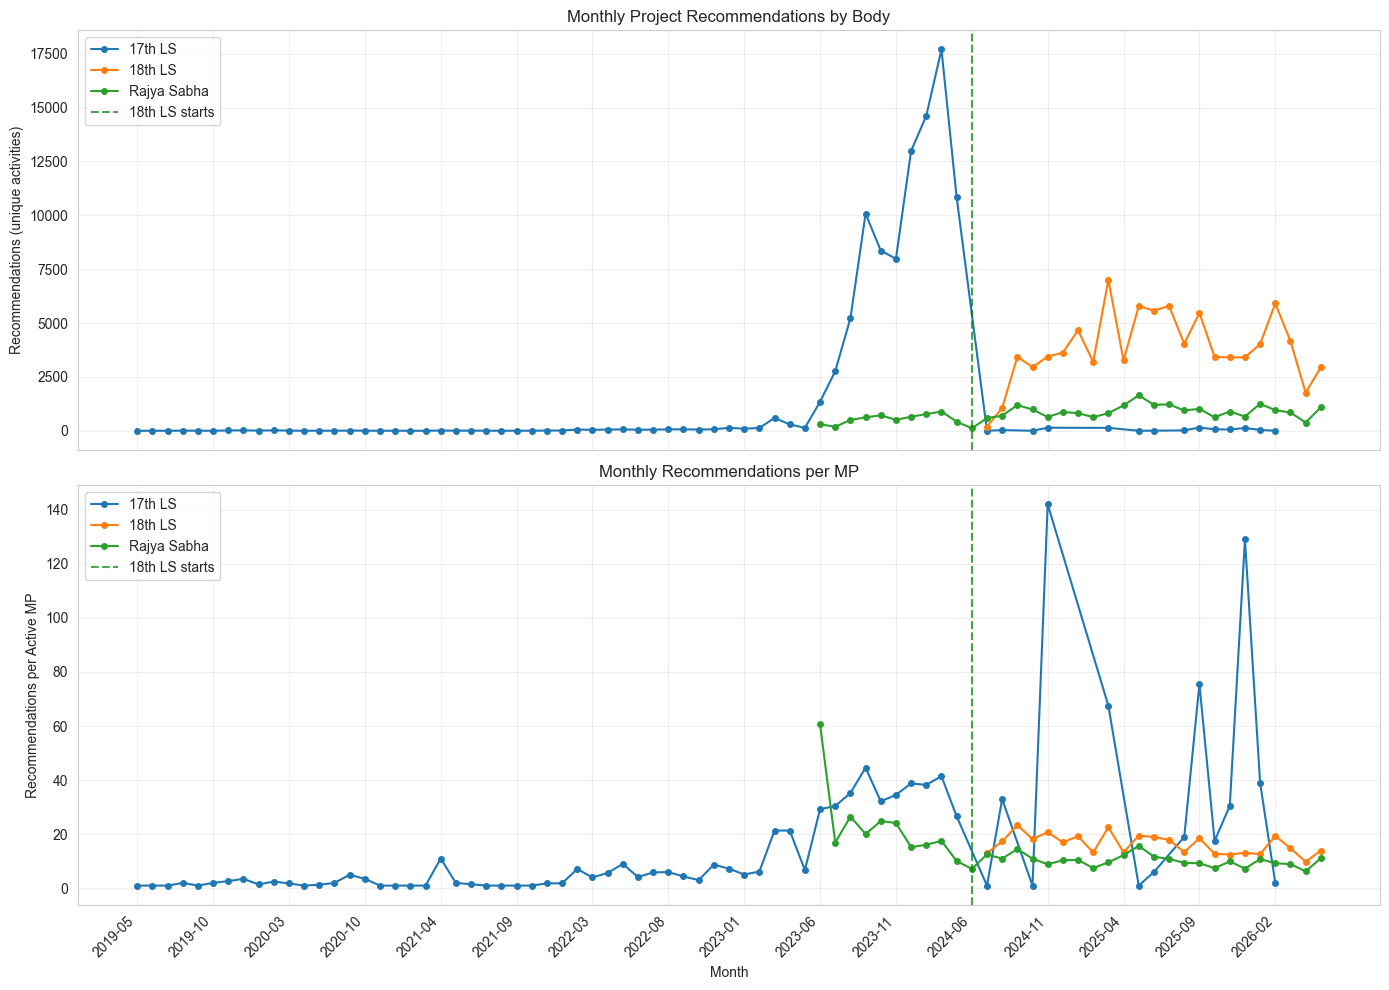

In [41]:
all_months_sorted = sorted(all_rec['month'].unique())
month_to_idx = {m: i for i, m in enumerate(all_months_sorted)}
month_labels = [str(m) for m in all_months_sorted]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for body, color, label in [('17th LS', COLORS[0], '17th LS'), ('18th LS', COLORS[1], '18th LS'), ('RS', COLORS[2], 'Rajya Sabha')]:
    body_data = all_rec[all_rec['body'] == body].copy()
    if len(body_data) == 0:
        continue
    body_data = body_data.sort_values('month')
    x_positions = [month_to_idx[m] for m in body_data['month']]
    axes[0].plot(x_positions, body_data['recommendations'], marker='o', label=label, color=color, markersize=4)
    axes[1].plot(x_positions, body_data['rec_per_mp'], marker='o', label=label, color=color, markersize=4)

election_months = ['2024-04', '2024-05']
for ax in axes:
    for em in election_months:
        if em in month_labels:
            idx = month_labels.index(em)
            ax.axvspan(idx - 0.5, idx + 0.5, alpha=0.15, color='red')
    if '2024-06' in month_labels:
        idx = month_labels.index('2024-06')
        ax.axvline(x=idx, color='green', linestyle='--', alpha=0.7, label='18th LS starts')

axes[0].set_ylabel('Recommendations (unique activities)')
axes[0].set_title('Monthly Project Recommendations by Body')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

axes[1].set_ylabel('Recommendations per Active MP')
axes[1].set_xlabel('Month')
axes[1].set_title('Monthly Recommendations per MP')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

step = max(1, len(month_labels) // 15)
axes[1].set_xticks(range(0, len(month_labels), step))
axes[1].set_xticklabels([month_labels[i] for i in range(0, len(month_labels), step)], rotation=45, ha='right')

plt.tight_layout()
plt.savefig(DATA_DIR / 'fig_11_monthly_recommendations.png', dpi=150)
plt.show()

In [42]:
print("MONTHLY RECOMMENDATIONS SUMMARY")
print("=" * 70)

for body in ['17th LS', '18th LS', 'RS']:
    body_data = all_rec[all_rec['body'] == body]
    if len(body_data) == 0:
        continue
    print(f"\n{body}:")
    print(f"  Date range: {body_data['month'].min()} to {body_data['month'].max()}")
    print(f"  Total recommendations: {body_data['recommendations'].sum():,}")
    print(f"  Monthly avg: {body_data['recommendations'].mean():,.0f} (std: {body_data['recommendations'].std():,.0f})")
    print(f"  Per-MP monthly avg: {body_data['rec_per_mp'].mean():.1f}")

MONTHLY RECOMMENDATIONS SUMMARY

17th LS:
  Date range: 2019-05 to 2026-02
  Total recommendations: 94,848
  Monthly avg: 1,375 (std: 3,748)
  Per-MP monthly avg: 15.9

18th LS:
  Date range: 2024-07 to 2026-05
  Total recommendations: 88,554
  Monthly avg: 3,850 (std: 1,610)
  Per-MP monthly avg: 16.3

RS:
  Date range: 2023-06 to 2026-05
  Total recommendations: 26,890
  Monthly avg: 791 (std: 330)
  Per-MP monthly avg: 14.0


### 10.2 Monthly Completions Timeline

Do completions spike before elections?

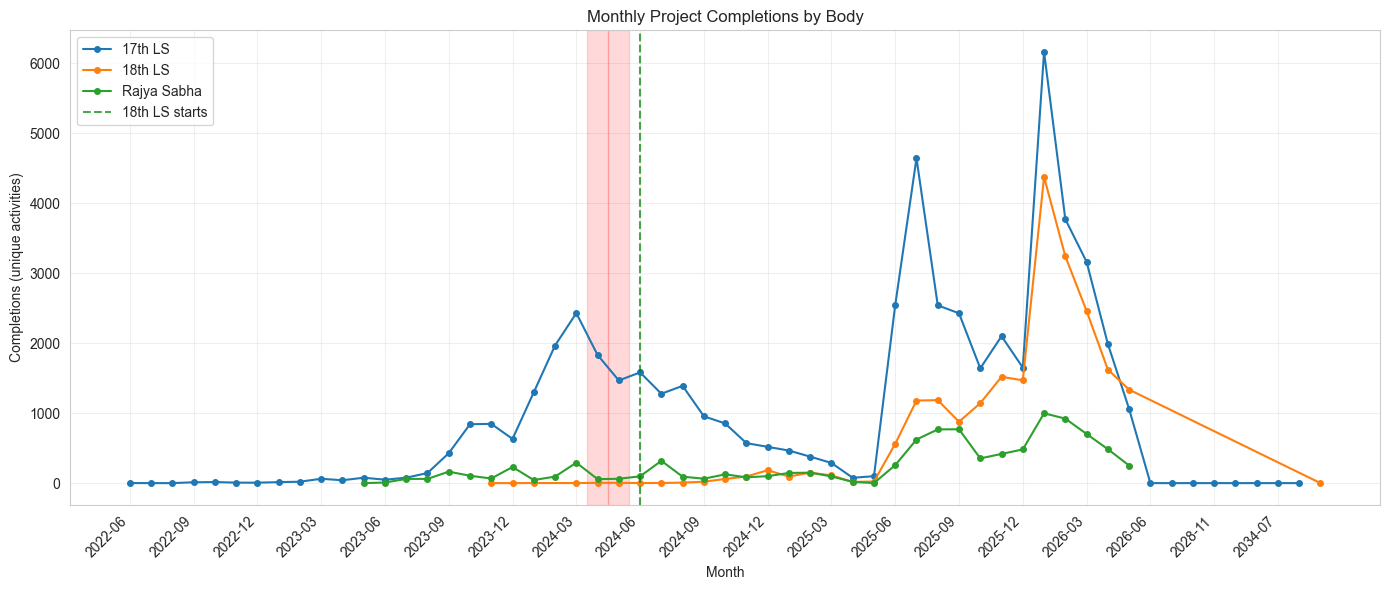

In [43]:
all_comp_months_sorted = sorted(all_comp['month'].unique())
comp_month_to_idx = {m: i for i, m in enumerate(all_comp_months_sorted)}
comp_month_labels = [str(m) for m in all_comp_months_sorted]

fig, ax = plt.subplots(figsize=(14, 6))

for body, color, label in [('17th LS', COLORS[0], '17th LS'), ('18th LS', COLORS[1], '18th LS'), ('RS', COLORS[2], 'Rajya Sabha')]:
    body_data = all_comp[all_comp['body'] == body].copy()
    if len(body_data) == 0:
        continue
    body_data = body_data.sort_values('month')
    x_positions = [comp_month_to_idx[m] for m in body_data['month']]
    ax.plot(x_positions, body_data['completions'], marker='o', label=label, color=color, markersize=4)

election_months = ['2024-04', '2024-05']
for em in election_months:
    if em in comp_month_labels:
        idx = comp_month_labels.index(em)
        ax.axvspan(idx - 0.5, idx + 0.5, alpha=0.15, color='red')
if '2024-06' in comp_month_labels:
    idx = comp_month_labels.index('2024-06')
    ax.axvline(x=idx, color='green', linestyle='--', alpha=0.7, label='18th LS starts')

ax.set_ylabel('Completions (unique activities)')
ax.set_xlabel('Month')
ax.set_title('Monthly Project Completions by Body')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

step = max(1, len(comp_month_labels) // 15)
ax.set_xticks(range(0, len(comp_month_labels), step))
ax.set_xticklabels([comp_month_labels[i] for i in range(0, len(comp_month_labels), step)], rotation=45, ha='right')

plt.tight_layout()
plt.savefig(DATA_DIR / 'fig_12_monthly_completions.png', dpi=150)
plt.show()

### 10.3 Pre/Post Election Comparison

Compare recommendation rates:
- Last 6 months of 17th LS (Dec 2023 - May 2024) vs First 6 months of 18th LS (Jun 2024 - Nov 2024)
- Test: Do incumbents push more projects before elections?

**CAVEAT:** This comparison is confounded by:
1. Different MPs (incumbents vs new entrants)
2. Different tenure phases (end of term vs start of term)
3. eSAKSHI data availability starting in 2023

Use with caution - observational patterns, not causal claims.

In [44]:
pre_election_months = [pd.Period('2023-12'), pd.Period('2024-01'), pd.Period('2024-02'), 
                       pd.Period('2024-03'), pd.Period('2024-04'), pd.Period('2024-05')]
post_election_months = [pd.Period('2024-06'), pd.Period('2024-07'), pd.Period('2024-08'),
                        pd.Period('2024-09'), pd.Period('2024-10'), pd.Period('2024-11')]

pre_ls17 = all_rec[(all_rec['body'] == '17th LS') & (all_rec['month'].isin(pre_election_months))]
post_ls18 = all_rec[(all_rec['body'] == '18th LS') & (all_rec['month'].isin(post_election_months))]

print("PRE/POST ELECTION COMPARISON")
print("=" * 70)
print("\nRecommendations in 6 months before election (17th LS: Dec 2023 - May 2024):")
print(f"  Total recommendations: {pre_ls17['recommendations'].sum():,}")
print(f"  Monthly avg: {pre_ls17['recommendations'].mean():,.0f}")
print(f"  Per-MP monthly avg: {pre_ls17['rec_per_mp'].mean():.1f}")

print("\nRecommendations in first 6 months (18th LS: Jun - Nov 2024):")
print(f"  Total recommendations: {post_ls18['recommendations'].sum():,}")
print(f"  Monthly avg: {post_ls18['recommendations'].mean():,.0f}")
print(f"  Per-MP monthly avg: {post_ls18['rec_per_mp'].mean():.1f}")

if pre_ls17['rec_per_mp'].mean() > 0:
    ratio = post_ls18['rec_per_mp'].mean() / pre_ls17['rec_per_mp'].mean()
    print(f"\n--> New MPs (18th LS) recommend {ratio:.1f}x as much per MP as outgoing MPs (17th LS)")

PRE/POST ELECTION COMPARISON

Recommendations in 6 months before election (17th LS: Dec 2023 - May 2024):
  Total recommendations: 56,142
  Monthly avg: 14,036
  Per-MP monthly avg: 36.3

Recommendations in first 6 months (18th LS: Jun - Nov 2024):
  Total recommendations: 11,081
  Monthly avg: 2,216
  Per-MP monthly avg: 18.5

--> New MPs (18th LS) recommend 0.5x as much per MP as outgoing MPs (17th LS)


In [45]:
pre_comp_ls17 = all_comp[(all_comp['body'] == '17th LS') & (all_comp['month'].isin(pre_election_months))]
post_comp_ls17 = all_comp[(all_comp['body'] == '17th LS') & (all_comp['month'].isin(post_election_months))]

print("COMPLETION VELOCITY AROUND ELECTION")
print("=" * 70)
print("\n17th LS completions in 6 months before election (Dec 2023 - May 2024):")
print(f"  Total completions: {pre_comp_ls17['completions'].sum():,}")
print(f"  Monthly avg: {pre_comp_ls17['completions'].mean():,.0f}")

print("\n17th LS completions in 6 months after election (Jun - Nov 2024):")
print(f"  Total completions: {post_comp_ls17['completions'].sum():,}")
print(f"  Monthly avg: {post_comp_ls17['completions'].mean():,.0f}")

if pre_comp_ls17['completions'].mean() > 0 and post_comp_ls17['completions'].mean() > 0:
    ratio = pre_comp_ls17['completions'].mean() / post_comp_ls17['completions'].mean()
    print(f"\n--> Pre-election completions were {ratio:.1f}x the post-election rate")

COMPLETION VELOCITY AROUND ELECTION

17th LS completions in 6 months before election (Dec 2023 - May 2024):
  Total completions: 9,623
  Monthly avg: 1,604

17th LS completions in 6 months after election (Jun - Nov 2024):
  Total completions: 6,629
  Monthly avg: 1,105

--> Pre-election completions were 1.5x the post-election rate


### 10.4 Cumulative Recommendations Over Time

Visualize the cumulative recommendation count with election marked.

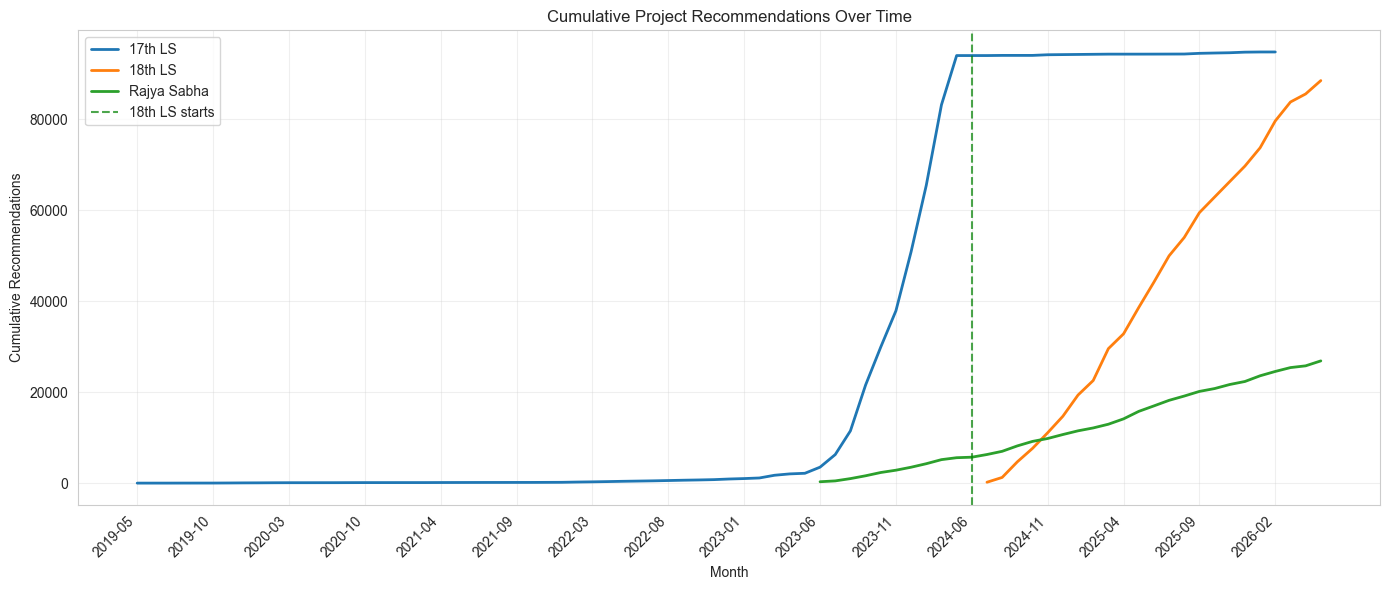

In [46]:
fig, ax = plt.subplots(figsize=(14, 6))

for body, color, label in [('17th LS', COLORS[0], '17th LS'), ('18th LS', COLORS[1], '18th LS'), ('RS', COLORS[2], 'Rajya Sabha')]:
    body_data = all_rec[all_rec['body'] == body].copy()
    if len(body_data) == 0:
        continue
    body_data = body_data.sort_values('month')
    body_data['cumulative'] = body_data['recommendations'].cumsum()
    x_positions = [month_to_idx[m] for m in body_data['month']]
    ax.plot(x_positions, body_data['cumulative'], label=label, color=color, linewidth=2)

for em in election_months:
    if em in month_labels:
        idx = month_labels.index(em)
        ax.axvspan(idx - 0.5, idx + 0.5, alpha=0.15, color='red')
if '2024-06' in month_labels:
    idx = month_labels.index('2024-06')
    ax.axvline(x=idx, color='green', linestyle='--', alpha=0.7, label='18th LS starts')

ax.set_ylabel('Cumulative Recommendations')
ax.set_xlabel('Month')
ax.set_title('Cumulative Project Recommendations Over Time')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

step = max(1, len(month_labels) // 15)
ax.set_xticks(range(0, len(month_labels), step))
ax.set_xticklabels([month_labels[i] for i in range(0, len(month_labels), step)], rotation=45, ha='right')

plt.tight_layout()
plt.show()

### 10.5 Election Year Effect Summary

In [47]:
print("=" * 70)
print("ELECTION YEAR EFFECT SUMMARY")
print("=" * 70)

print("\n*** IMPORTANT CAVEATS ***")
print("Cross-tenure comparisons are confounded by:")
print("  - Data availability (eSAKSHI only from 2023)")
print("  - Different tenure phases (end vs start)")
print("  - Different MPs (incumbents vs new)")

print("\n1. RECOMMENDATION PATTERNS (observational only):")
print("   - 17th LS: Late-term data only (Apr 2023 - May 2024)")
print("   - 18th LS: Early-term data (Jun 2024 - present)")
if len(pre_ls17) > 0 and len(post_ls18) > 0:
    print(f"   - Pre-election (17th): {pre_ls17['rec_per_mp'].mean():.1f} recs/MP/month")
    print(f"   - Post-election (18th): {post_ls18['rec_per_mp'].mean():.1f} recs/MP/month")
    print("   (NOT directly comparable due to confounds)")

print("\n2. COMPLETION PATTERNS (observational only):")
if len(pre_comp_ls17) > 0:
    print(f"   - Pre-election avg: {pre_comp_ls17['completions'].mean():,.0f} completions/month")
if len(post_comp_ls17) > 0:
    print(f"   - Post-election avg: {post_comp_ls17['completions'].mean():,.0f} completions/month")

print("\n3. WHAT WE CAN SAY:")
print("   - There are observable differences in patterns around elections")
print("   - Causal attribution requires careful research design")
print("   - Within-tenure patterns (e.g., 18th LS only) are more reliable")

print("\n4. FIGURES SAVED:")
print("   - fig_11_monthly_recommendations.png")
print("   - fig_12_monthly_completions.png")

ELECTION YEAR EFFECT SUMMARY

*** IMPORTANT CAVEATS ***
Cross-tenure comparisons are confounded by:
  - Data availability (eSAKSHI only from 2023)
  - Different tenure phases (end vs start)
  - Different MPs (incumbents vs new)

1. RECOMMENDATION PATTERNS (observational only):
   - 17th LS: Late-term data only (Apr 2023 - May 2024)
   - 18th LS: Early-term data (Jun 2024 - present)
   - Pre-election (17th): 36.3 recs/MP/month
   - Post-election (18th): 18.5 recs/MP/month
   (NOT directly comparable due to confounds)

2. COMPLETION PATTERNS (observational only):
   - Pre-election avg: 1,604 completions/month
   - Post-election avg: 1,105 completions/month

3. WHAT WE CAN SAY:
   - There are observable differences in patterns around elections
   - Causal attribution requires careful research design
   - Within-tenure patterns (e.g., 18th LS only) are more reliable

4. FIGURES SAVED:
   - fig_11_monthly_recommendations.png
   - fig_12_monthly_completions.png
